In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pygeohash as pgh
import warnings

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.8 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor
from sklearn.cluster import KMeans
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

In [ ]:
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

In [ ]:
train = pd.read_csv("train.csv",index_col='Index')
test = pd.read_csv("test.csv",index_col='Index')

In [ ]:
print(train.shape)
print(test.shape)

(77299, 10)
(41778, 9)


In [ ]:
train.sample(6)

,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
Index,,,,,,,,,,
66649,qp09d2,48,23:0,0.259272,Street,1,Not Allowed,Yes,27.545747,Sunny
42863,qp09f7,48,12:0,0.056033,Residential,2,Not Allowed,Yes,16.983071,Foggy
48461,qp092j,48,13:45,0.172009,Residential,2,Not Allowed,Yes,15.710059,Foggy
26433,qp097g,48,7:30,0.059736,Residential,2,Not Allowed,Yes,26.638174,Sunny
44219,qp03re,48,12:30,0.081899,Residential,3,Allowed,Yes,6.258062,Snowy
12253,qp09f5,48,3:30,0.005140,Residential,2,Not Allowed,Yes,19.632126,Sunny


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 77299 entries, 0 to 77298
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   geohash        77299 non-null  object 
 1   day            77299 non-null  int64  
 2   timestamp      77299 non-null  object 
 3   demand         77299 non-null  float64
 4   RoadType       76699 non-null  object 
 5   NumberofLanes  77299 non-null  int64  
 6   LargeVehicles  77299 non-null  object 
 7   Landmarks      77299 non-null  object 
 8   Temperature    74804 non-null  float64
 9   Weather        76502 non-null  object 
dtypes: float64(2), int64(2), object(6)
memory usage: 6.5+ MB


In [ ]:
# Checking for missing values in each training column
train.isnull().sum()

,0
geohash,0
day,0
timestamp,0
demand,0
RoadType,600
NumberofLanes,0
LargeVehicles,0
Landmarks,0
Temperature,2495
Weather,797


In [ ]:
# Checking for missing values in each test column
test.isna().sum()

,0
geohash,0
day,0
timestamp,0
RoadType,324
NumberofLanes,0
LargeVehicles,0
Landmarks,0
Temperature,1349
Weather,431


In [ ]:
# Perform missing value imputation for both datasets
for df in [train,test]:
  df['Temperature'].fillna(df['Temperature'].median(),inplace=True)
  df['RoadType'].fillna(df['RoadType'].mode()[0],inplace=True)
  df['Weather'].fillna(df['Weather'].mode()[0],inplace=True)

In [ ]:
# No missing values
print(train.isna().sum().sum())
print(test.isna().sum().sum())

0
0


In [ ]:
# Number of unique values in categorical features
for col in train.select_dtypes(include='object'):
    print(col,train[col].nunique())

geohash 1249
timestamp 96
RoadType 3
LargeVehicles 2
Landmarks 2
Weather 4


In [ ]:
# Category distribution for important features
for col in ['RoadType','Weather','Landmarks','LargeVehicles','day','NumberofLanes']:
    print(train[col].value_counts())
    print()

RoadType
Residential    69830
Street          3909
Highway         3560
Name: count, dtype: int64

Weather
Sunny    28514
Rainy    20824
Foggy    20243
Snowy     7718
Name: count, dtype: int64

Landmarks
Yes    52042
No     25257
Name: count, dtype: int64

LargeVehicles
Not Allowed    50673
Allowed        26626
Name: count, dtype: int64

day
48    69427
49     7872
Name: count, dtype: int64

NumberofLanes
1    27411
2    24127
3    23919
4      926
5      916
Name: count, dtype: int64



In [ ]:
# Average demand for each geohash location
train.groupby('geohash')['demand'].agg(['mean','count']).sort_values(by='mean',ascending=False)

,mean,count
geohash,,
qp09d9,0.960715,105
qp09ft,0.868850,105
qp09e5,0.864989,105
qp09d8,0.669318,105
qp096x,0.665630,105
...,...,...
qp09bv,0.000922,1
qp093h,0.000815,1
qp09k7,0.000793,1


In [ ]:
# Statistical summary of target variable
train['demand'].describe()

,demand
count,7.729900e+04
mean,9.394238e-02
std,1.421905e-01
min,6.245650e-07
25%,1.822723e-02
50%,4.775994e-02
75%,1.085951e-01
max,1.000000e+00


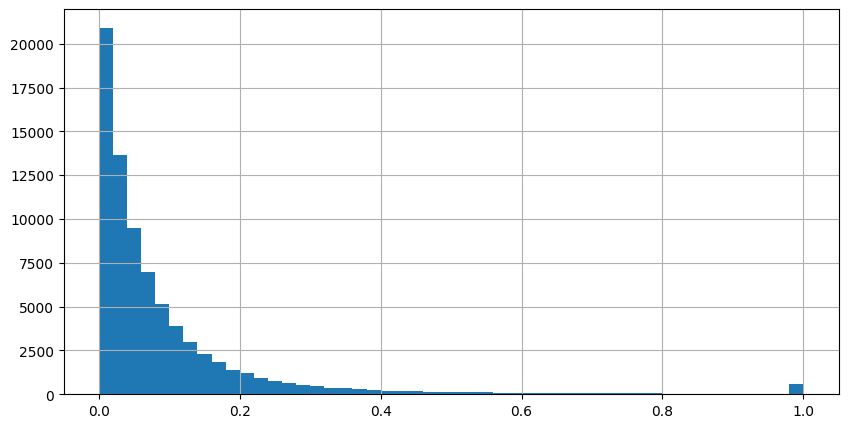

In [ ]:
# Plot histogram to understand demand distribution
train['demand'].hist(bins=50,figsize=(10,5))
plt.show()

In [ ]:
# Statistical summary of temperature
train['Temperature'].describe()

,Temperature
count,77299.000000
mean,16.404619
std,7.240083
min,-14.935097
25%,11.624189
50%,16.382587
75%,21.115592
max,48.251433


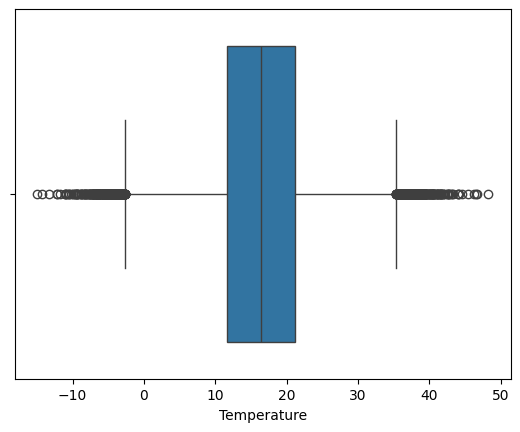

In [ ]:
# Visualize temperature outliers using boxplot
sns.boxplot(x=train['Temperature'])
plt.show()

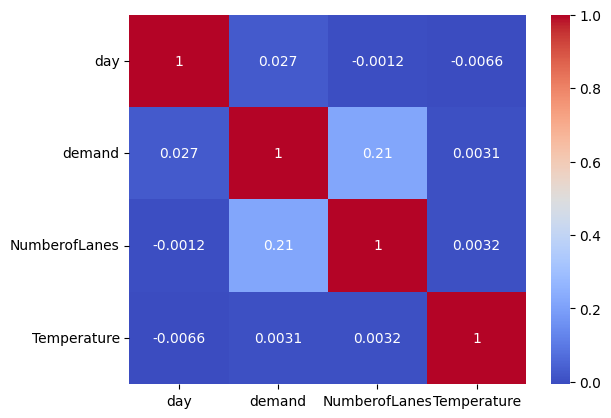

In [ ]:
# Correlation matrix for numerical features
corr = train.corr(numeric_only=True)

sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

In [ ]:
# Checking for deplicated rows
train.duplicated().sum()

np.int64(0)

In [ ]:
# Extract hour and minute from timestamp
for df in [train, test]:
  df[['hour','minute']] = (df['timestamp'].str.split(':', expand=True).astype(int))

In [ ]:
train[['timestamp','hour','minute']].sample(6)

,timestamp,hour,minute
Index,,,
28986,8:15,8,15
18548,5:15,5,15
31925,9:0,9,0
3302,1:0,1,0
11747,3:30,3,30
8275,2:30,2,30


In [ ]:
# Convert hour into traffic-related time categories
def get_time_slot(hour):

    if 0 <= hour < 6:
        return "Night"

    elif 6 <= hour < 10:
        return "MorningPeak"

    elif 10 <= hour < 16:
        return "Midday"

    elif 16 <= hour < 20:
        return "EveningPeak"

    else:
        return "LateEvening"

In [ ]:
for df in [train,test]:
    df['TimeSlot'] = df['hour'].apply(get_time_slot)

In [ ]:
# Define traffic peak hours
peak_hours = [7,8,9,17,18,19]

for df in [train,test]:
    df['is_peak_hour'] = df['hour'].isin(peak_hours).astype(int)

In [ ]:
# Encode hour cyclically to preserve time continuity
for df in [train,test]:
  df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
  df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)

In [ ]:
train['day'].value_counts()

,count
day,
48,69427
49,7872


In [ ]:
# Encoding cyclically
for df in [train,test]:
  df['day_sin'] = np.sin(2*np.pi*df['day']/49)
  df['day_cos'] = np.cos(2*np.pi*df['day']/49)

In [ ]:
# Converting categorical values to binary
mapping = {
    'Allowed':1,
    'Not Allowed':0
}
for df in [train,test]:
  df['LargeVehicles']=df['LargeVehicles'].map(mapping)

In [ ]:
mapping = {
    'Yes':1,
    'No':0
}
for df in [train,test]:
  df['Landmarks']=df['Landmarks'].map(mapping)

In [ ]:
# Convert geohash into latitude and longitude
for df in [train,test]:
  df[['latitude', 'longitude']] = pd.DataFrame(df['geohash'].apply(pgh.decode).tolist(), index=df.index)

In [ ]:
#Rush Hour Categories
for df in [train,test]:
  df['hour_bin'] = pd.cut(
    df['hour'],
    bins=[0,6,10,16,20,24],
    labels=[0,1,2,3,4],
    include_lowest=True
)

In [ ]:
#Temperature Groups
for df in [train,test]:
  df['temp_bin'] = pd.cut(
    df['Temperature'],
    bins=5,
    labels=False
)

In [ ]:
for df in [train,test]:
  df['Weather_RoadType'] = df['Weather'].astype(str) + "_" +df['RoadType'].astype(str)

  df['Weather_Peak'] = df['Weather'].astype(str) + "_" +df['is_peak_hour'].astype(str)

In [ ]:
coords = train[['latitude','longitude']]
kmeans = KMeans(n_clusters=20,random_state=42)

train['location_cluster'] = kmeans.fit_predict(coords)
test['location_cluster'] = kmeans.predict(
    test[['latitude','longitude']]
)

In [ ]:
print(train.shape)
print(test.shape)

(77299, 25)
(41778, 24)


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 77299 entries, 0 to 77298
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   geohash           77299 non-null  object  
 1   day               77299 non-null  int64   
 2   timestamp         77299 non-null  object  
 3   demand            77299 non-null  float64 
 4   RoadType          77299 non-null  object  
 5   NumberofLanes     77299 non-null  int64   
 6   LargeVehicles     77299 non-null  int64   
 7   Landmarks         77299 non-null  int64   
 8   Temperature       77299 non-null  float64 
 9   Weather           77299 non-null  object  
 10  hour              77299 non-null  int64   
 11  minute            77299 non-null  int64   
 12  TimeSlot          77299 non-null  object  
 13  is_peak_hour      77299 non-null  int64   
 14  hour_sin          77299 non-null  float64 
 15  hour_cos          77299 non-null  float64 
 16  day_sin           77299 non

In [ ]:
# Remove target and unused columns from training and test data
X = train.drop(['timestamp','demand'],axis=1)
y = train['demand']

X_test = test.drop(['timestamp'],axis=1)


In [ ]:
cat_cols = [
    'RoadType',
    'Weather',
    'geohash',
    'TimeSlot',
    'Weather_RoadType',
    'Weather_Peak'
]

for col in cat_cols:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 77299 entries, 0 to 77298
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   geohash           77299 non-null  category
 1   day               77299 non-null  int64   
 2   RoadType          77299 non-null  category
 3   NumberofLanes     77299 non-null  int64   
 4   LargeVehicles     77299 non-null  int64   
 5   Landmarks         77299 non-null  int64   
 6   Temperature       77299 non-null  float64 
 7   Weather           77299 non-null  category
 8   hour              77299 non-null  int64   
 9   minute            77299 non-null  int64   
 10  TimeSlot          77299 non-null  category
 11  is_peak_hour      77299 non-null  int64   
 12  hour_sin          77299 non-null  float64 
 13  hour_cos          77299 non-null  float64 
 14  day_sin           77299 non-null  float64 
 15  day_cos           77299 non-null  float64 
 16  latitude          77299 non

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=5
)

In [ ]:
cat_features = cat_cols + ['hour_bin']

In [ ]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lgb_preds = np.zeros(len(X_test))

for train_idx, valid_idx in kf.split(X):

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    lgb_model_k = LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05
    )

    lgb_model_k.fit(X_train, y_train)

    lgb_preds += lgb_model_k.predict(X_test) / 5

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008041 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1560
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 23
[LightGBM] [Info] Start training from score 0.093784
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011148 seconds.
You can set `force_row_wise=

In [ ]:
lgb_model_k.score(X,y)

0.9724502412978402

In [ ]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_preds = np.zeros(len(X))
cat_preds = np.zeros(len(X_test))

rmse_scores = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X)):

    print(f"\nFold {fold+1}")

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    cat_model_k = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=8,
        loss_function='RMSE',
        eval_metric='RMSE',
        verbose=200
    )

    cat_model_k.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        use_best_model=True,
        cat_features=cat_features
    )

    valid_pred = cat_model_k.predict(X_valid)

    oof_preds[valid_idx] = valid_pred

    fold_rmse = np.sqrt(
        mean_squared_error(
            y_valid,
            valid_pred
        )
    )

    rmse_scores.append(fold_rmse)

    print(f"Fold RMSE: {fold_rmse:.4f}")

    cat_preds += cat_model_k.predict(X_test) / 5


Fold 1
0:	learn: 0.1367009	test: 0.1366485	best: 0.1366485 (0)	total: 113ms	remaining: 1m 53s
200:	learn: 0.0370085	test: 0.0369423	best: 0.0369423 (200)	total: 27.8s	remaining: 1m 50s
400:	learn: 0.0329096	test: 0.0336636	best: 0.0336636 (400)	total: 1m	remaining: 1m 30s
600:	learn: 0.0307431	test: 0.0323012	best: 0.0323012 (600)	total: 1m 48s	remaining: 1m 11s
800:	learn: 0.0292446	test: 0.0313937	best: 0.0313937 (800)	total: 2m 18s	remaining: 34.4s
999:	learn: 0.0282314	test: 0.0309852	best: 0.0309850 (998)	total: 2m 50s	remaining: 0us

bestTest = 0.03098502901
bestIteration = 998

Shrink model to first 999 iterations.
Fold RMSE: 0.0310

Fold 2
0:	learn: 0.1360273	test: 0.1394659	best: 0.1394659 (0)	total: 114ms	remaining: 1m 53s
200:	learn: 0.0369727	test: 0.0381965	best: 0.0381965 (200)	total: 27.3s	remaining: 1m 48s
400:	learn: 0.0327803	test: 0.0347722	best: 0.0347722 (400)	total: 56.7s	remaining: 1m 24s
600:	learn: 0.0305776	test: 0.0333307	best: 0.0333307 (600)	total: 1m 33s	

In [ ]:
cat_model_k.score(X,y)

np.float64(0.959764174030049)

In [ ]:
blend_pred = (
    0.5 * cat_preds +
    0.5 * lgb_preds
)